In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install -q pyspark findspark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# No need to download Spark—pip installation includes Spark JARs

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ColabSpark").getOrCreate()
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[Load] Dataset shape: (25403, 36) | Target positive rate: 0.152
Logistic Regression: mean AUC = 0.805 ± 0.005
Decision Tree: mean AUC = 0.767 ± 0.006
Random Forest: mean AUC = 0.800 ± 0.006


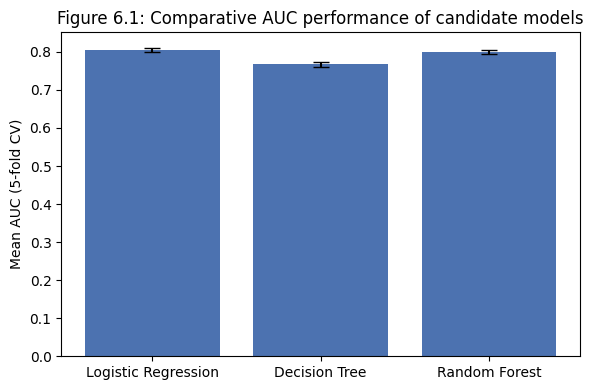

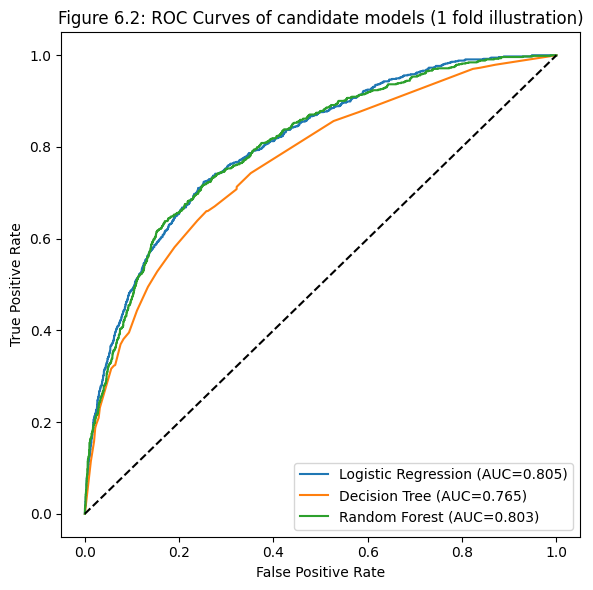

In [5]:
# =====================================================
# 6. Data-mining Algorithm(s) Selection (Leakage-safe version)
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------
# 1) Load prepared data
# -----------------------------
base_dir = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"
df_model = pd.read_parquet(f"{base_dir}/final_selected_table.parquet")

# -----------------------------
# 2) Define features (X) and target (y)
# -----------------------------
# Drop all possible identifiers and target-related columns
drop_cols = [c for c in df_model.columns if "RID" in c or "AMIGR" in c]
X = df_model.drop(columns=drop_cols, errors="ignore")

# Binary target: 1 = migraine, 0 = non-migraine
y = df_model["AMIGR"].map({1: 1, 2: 0}).astype(int)

print(f"[Load] Dataset shape: {X.shape} | Target positive rate: {y.mean():.3f}")

# -----------------------------
# 3) Candidate models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        penalty="l2",
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=50,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42
    )
}

# -----------------------------
# 4) Cross-validation AUC (no leakage)
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mean_scores, std_scores = {}, {}

for name, model in models.items():
    # Each CV fold trains from scratch (no global fit leakage)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    mean_scores[name] = scores.mean()
    std_scores[name] = scores.std()
    print(f"{name}: mean AUC = {scores.mean():.3f} ± {scores.std():.3f}")

# -----------------------------
# 5) Plot Figure 6.1: AUC comparison
# -----------------------------
plt.figure(figsize=(6, 4))
plt.bar(mean_scores.keys(), mean_scores.values(), yerr=std_scores.values(),
        capsize=6, color="#4C72B0")
plt.ylabel("Mean AUC (5-fold CV)")
plt.title("Figure 6.1: Comparative AUC performance of candidate models")
plt.tight_layout()
plt.savefig(f"{base_dir}/fig_6_1_model_auc.png", dpi=200)
plt.show()

# -----------------------------
# 6) ROC Curves (first fold illustration)
# -----------------------------
plt.figure(figsize=(6, 6))

for name, model in models.items():
    train_idx, test_idx = next(cv.split(X, y))
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = model.predict_proba(X.iloc[test_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y.iloc[test_idx], y_prob)
    auc = roc_auc_score(y.iloc[test_idx], y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 6.2: ROC Curves of candidate models (1 fold illustration)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{base_dir}/fig_6_2_roc.png", dpi=200)
plt.show()


--- 6.1 Exploratory Analysis of Data Mining Algorithms ---
Data split into training (20433 rows) and testing (4970 rows) sets.
Training and evaluating Logistic Regression...
--> Logistic Regression Test AUC = 0.7990
Training and evaluating Random Forest...
--> Random Forest Test AUC = 0.7846

--- Generating Comparative AUC Bar Chart ---


/tmp/ipython-input-160304190.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=results_pd.sort_values('AUC', ascending=False), palette='viridis')


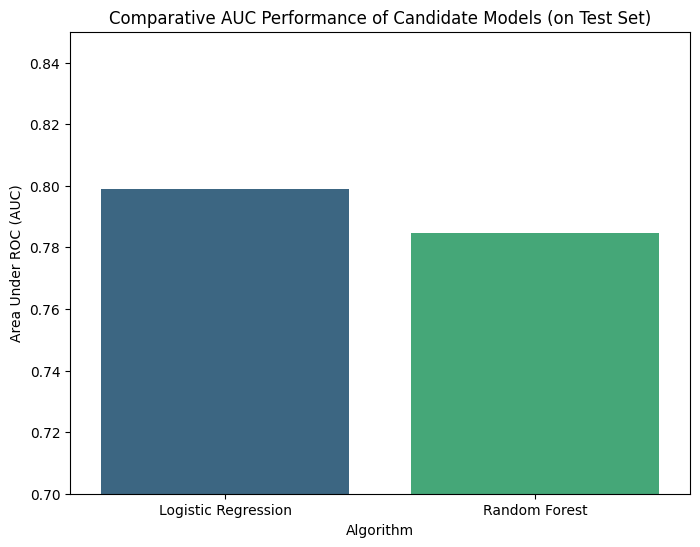

In [ ]:
# Cell for Section 6: Exploratory Algorithm Analysis (Final Robust Version)
import pyspark.sql.functions as F
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- 6.1 Exploratory Analysis of Data Mining Algorithms ---")

# 1. Load the final prepared data from your Google Drive
input_path = "/content/drive/MyDrive/Infosys722/modeling_final.parquet"
final_data = spark.read.parquet(input_path)

# --- Handle Class Imbalance by calculating weights ---
balance_ratio = final_data.filter(F.col("label") == 0).count() / final_data.count()
df_balanced = final_data.withColumn("classWeightCol",
    F.when(F.col("label") == 1, balance_ratio)
     .otherwise(1 - balance_ratio)
)

# 2. Perform a single Train/Test Split for this exploratory analysis
(train_data, test_data) = df_balanced.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()
print(f"Data split into training ({train_data.count()} rows) and testing ({test_data.count()} rows) sets.")

# 3. Define Candidate Algorithms
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="classWeightCol")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, seed=42)
# We are removing Decision Tree from the direct comparison as previously discussed
models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

# 4. Train each model and evaluate AUC
auc_results = {}
evaluator = BinaryClassificationEvaluator(metricName="areaUnderROC")

for name, model in models.items():
    print(f"Training and evaluating {name}...")
    fitted_model = model.fit(train_data)
    predictions = fitted_model.transform(test_data)
    auc = evaluator.evaluate(predictions)
    auc_results[name] = auc
    print(f"--> {name} Test AUC = {auc:.4f}")

# 5. Plot Comparative Performance Bar Chart
print("\n--- Generating Comparative AUC Bar Chart ---")
results_pd = pd.DataFrame(list(auc_results.items()), columns=['Model', 'AUC'])
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='AUC', data=results_pd.sort_values('AUC', ascending=False), palette='viridis')
plt.title("Comparative AUC Performance of Candidate Models (on Test Set)")
plt.ylabel("Area Under ROC (AUC)")
plt.xlabel("Algorithm")
plt.ylim(0.7, 0.85)
plt.show()

--- 6.1 Exploratory Analysis of Data Mining Algorithms ---
Data split into training (20433 rows) and testing (4970 rows) sets.
Training and evaluating Logistic Regression...
--> Logistic Regression Test AUC = 0.7990
Training and evaluating Random Forest...
--> Random Forest Test AUC = 0.7846

--- Generating Comparative AUC Bar Chart ---


/tmp/ipython-input-580945481.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=results_pd.sort_values('AUC', ascending=False), palette='viridis')


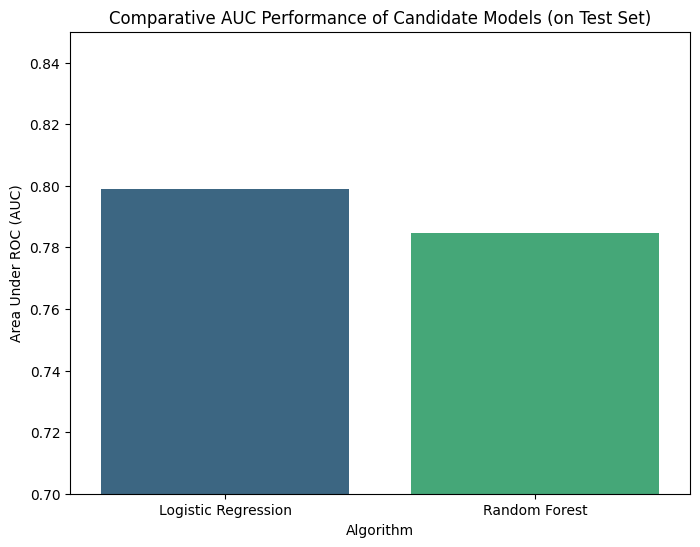


--- Generating Illustrative ROC Curves ---


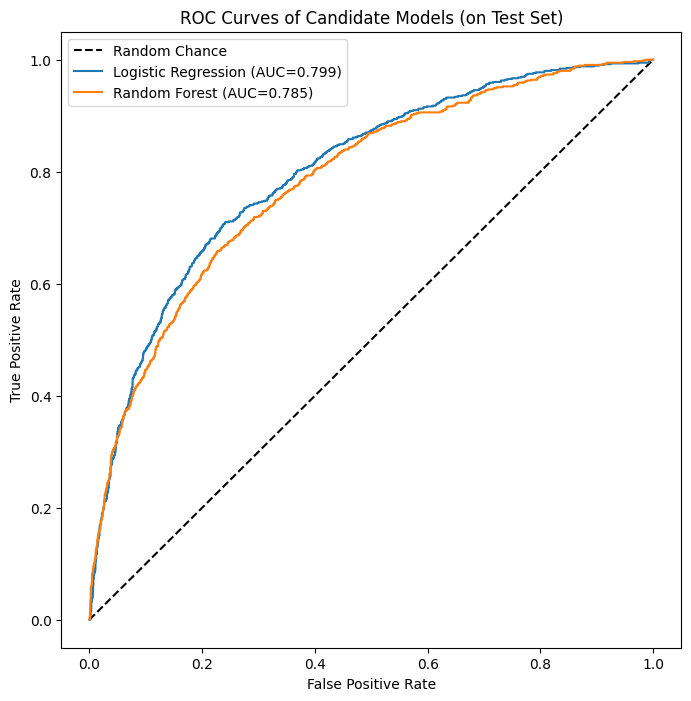

In [ ]:
# Cell for Section 6: Exploratory Algorithm Analysis (Using scikit-learn for plotting)
import pyspark.sql.functions as F
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Import the specific sklearn functions we will use
from sklearn.metrics import roc_curve, auc

print("--- 6.1 Exploratory Analysis of Data Mining Algorithms ---")

# 1. Load the final prepared data
input_path = "/content/drive/MyDrive/Infosys722/modeling_final.parquet"
final_data = spark.read.parquet(input_path)

# --- Handle Class Imbalance by calculating weights ---
balance_ratio = final_data.filter(F.col("label") == 0).count() / final_data.count()
df_balanced = final_data.withColumn("classWeightCol",
    F.when(F.col("label") == 1, balance_ratio)
     .otherwise(1 - balance_ratio)
)

# 2. Perform a single Train/Test Split
(train_data, test_data) = df_balanced.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()
print(f"Data split into training ({train_data.count()} rows) and testing ({test_data.count()} rows) sets.")

# 3. Define Candidate Algorithms
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="classWeightCol")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, seed=42)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

# 4. Train models, evaluate, and collect data for plotting
auc_results = {}
roc_plot_data = {}
evaluator = BinaryClassificationEvaluator(metricName="areaUnderROC")

for name, model in models.items():
    print(f"Training and evaluating {name}...")

    fitted_model = model.fit(train_data)
    predictions = fitted_model.transform(test_data)

    # Calculate AUC using PySpark's evaluator
    auc_score = evaluator.evaluate(predictions)
    auc_results[name] = auc_score
    print(f"--> {name} Test AUC = {auc_score:.4f}")

    # --- NEW METHOD FOR ROC CURVE ---
    # Select label and probability columns and convert to Pandas
    preds_pd = predictions.select("label", "probability").toPandas()

    # Extract true labels (y_true) and probabilities for the positive class (y_scores)
    y_true = preds_pd['label']
    y_scores = preds_pd['probability'].apply(lambda p: p[1])

    # Use sklearn's roc_curve function
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    # Store the results for plotting
    roc_plot_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_score}

# 5. Plot Comparative Performance Bar Chart
print("\n--- Generating Comparative AUC Bar Chart ---")
results_pd = pd.DataFrame(list(auc_results.items()), columns=['Model', 'AUC'])
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='AUC', data=results_pd.sort_values('AUC', ascending=False), palette='viridis')
plt.title("Comparative AUC Performance of Candidate Models (on Test Set)")
plt.ylabel("Area Under ROC (AUC)")
plt.xlabel("Algorithm")
plt.ylim(0.7, 0.85)
plt.show()

# 6. Show the ROC Curve Plot using the collected data
print("\n--- Generating Illustrative ROC Curves ---")
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

for name, data in roc_plot_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC={data['auc']:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Candidate Models (on Test Set)")
plt.legend()
plt.show()